<a href="https://colab.research.google.com/github/Moncayo1329/Rocket-Engine-calculation/blob/main/Rocket_Engine_Thermodynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cantera
import numpy as np
import cantera as ct
import scipy.optimize as so
import matplotlib.pyplot as plt
from scipy.constants import g
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.2 MB/s eta 0:00:00


In [3]:
# global parameters of the combustion
config = {
    'fuel': None,
    'oxidizer': None,
    'equilibrium_species': [],
    'of_stoich': None,
    'of_min': None,
    'of_max': None,
    'of_step': None,
    'chamber_pressures': [],
    'initial_temperature': None,
    'expansion_ratio': None,
    'equilibrium_type': None
}
# import thermodynamics data
multi_line = None
with open("/content/thermo_input.txt", "r") as file:
    for line in file:
        if line.startswith('#') or not line.strip():
            multi_line = None
            continue
        if ':' in line:
            key, _, value = line.partition(':')
            key   = key.strip().lower()
            value = value.strip()
            if key == 'species':
                key = 'equilibrium_species'
            if key == 'chamber_pressures_bar':
                key = 'chamber_pressures'
        elif multi_line == 'chamber_pressures':
            config[multi_line].append(float(line.strip()))
        elif multi_line == 'equilibrium_species':
            config[multi_line].append(line.strip())
        if multi_line == None and (key == 'equilibrium_species' or key == 'chamber_pressures'):
            multi_line = key
        if value:
            if key not in ['fuel', 'oxidizer','equilibrium_species', 'equilibrium_type']:
                value = float(value)
            config[key] = value
config

{'fuel': 'H2',
 'oxidizer': 'O2',
 'equilibrium_species': ['H2', 'O2', 'H2O', 'OH', 'O', 'H'],
 'of_stoich': 8.0,
 'of_min': 3.0,
 'of_max': 8.5,
 'of_step': 0.25,
 'chamber_pressures': [10.0, 50.0, 200.0],
 'initial_temperature': 298.0,
 'expansion_ratio': 40.0,
 'equilibrium_type': 'HP'}

In [4]:
def equilibrium(OF, P_chamber, T0):
    """Calculates the equilibrium of the propellant for a given mixture ratio and chamber pressure using the Cantera library
    Parameters
    ----------
    OF: float
        propellant mixture ratio
    P_chamber: float
        chamber pressure [bar]
    T0: float
        initial temperature [K]
    Returns
    -------
    Tc: float
        adiabatic flame temperature [K]
    fractions: dict
        mole fractions of each species in the gas mixture
    M: float
        mean molecular weight of the gas mixture [kg/mol]
    gamma: float
        specific heat coefficient fraction of the gas mixture
    cp: float
        specific heat coefficient under constant pressure conditions of the gas mixture [J/kg K^-1]
    """
    gas = ct.Solution(thermo='ideal-gas', kinetics='gas', species=ct.Species.list_from_file('nasa_gas.yaml'))   # thermodynamic database
    P_chamber*=1e5                          # converting from bar to Pa
    fuel     = f"{config['fuel']}:1"        # adapting to Cantera's syntax
    oxidizer = f"{config['oxidizer']}:1"    # adapting to Cantera's syntax
    gas.set_equivalence_ratio(config['of_stoich']/OF, fuel, oxidizer)
    gas.TP = T0, P_chamber
    gas.equilibrate(config['equilibrium_type'])
    return gas.T, {sp: gas.mole_fraction_dict().get(sp, 0.0) for sp in config['equilibrium_species']}, gas.mean_molecular_weight, gas.cp/gas.cv, gas.cp

In [5]:
def nozzle(Tc, M, gamma, P_chamber):
    """Calculates nozzle performance parameters for the given combustion state
    Parameters
    ----------
    Tc: float
        adiabatic flame temperature [K]
    M: float
        mean molecular weight of the gas mixture [kg/mol]
    gamma: float
        specific heat coefficient fraction of the gas mixture
    P_chamber: float
        chamber pressure [bar]
    Returns
    -------
    ve: float
        exhaust velocity [m/s]
    c_star: float
        characteritic velocity [m/s]
    Isp: float
        specific impulse [s]
    """
    P_chamber*=1e5                                                      # converting from bar to Pa
    R = ct.gas_constant/M                                               # specific gas constant [J/kg K^-1]
    Me = so.brentq(lambda M: (1/M)*((2/(gamma+1))*(1+0.5*(gamma-1)* M**2))**((gamma+1)/(2*(gamma-1))) - config['expansion_ratio'], 1.01, 30)    # exit Mach number from area ratio
    Pe = P_chamber * (1+(gamma-1)/2*Me**2)**(-gamma/(gamma-1))          # exit pressure
    ve = np.sqrt(2*gamma/(gamma-1) * R*Tc * (1 - (Pe/P_chamber)**((gamma-1)/gamma)))
    Gamma = np.sqrt(gamma) * (2/(gamma+1))**((gamma+1)/(2*(gamma-1)))   # Vandenkerckhove function
    c_star = np.sqrt(R*Tc) / Gamma
    Isp = ve/g + (Pe * config['expansion_ratio'] * c_star) / (P_chamber * g)
    return ve, c_star, Isp

In [6]:
results = {}
OF_range = np.arange(config['of_min'], config['of_max']+config['of_step'], config['of_step'])
for P in config['chamber_pressures']:
    results[P] = {}
    for OF in OF_range:
        Tc, fractions, M, gamma, cp = equilibrium(OF, P, config['initial_temperature'])
        results[P][OF] = {
            'Tc':        Tc,
            'fractions': fractions,
            'M':         M,
            'gamma':     gamma,
            'cp':        cp,
        }

In [7]:
for P in results:
    for OF in results[P]:
        r = results[P][OF]
        ve, c_star, Isp = nozzle(r['Tc'], r['M'], r['gamma'], P)
        results[P][OF]['ve']     = ve
        results[P][OF]['c_star'] = c_star
        results[P][OF]['Isp']    = Isp

<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3779/3829654288.py:23: SyntaxWarning: invalid escape sequence '\g'
  (2, 0, 'gamma', '$\gamma$ [-]', 'Specific Heat Ratio'),


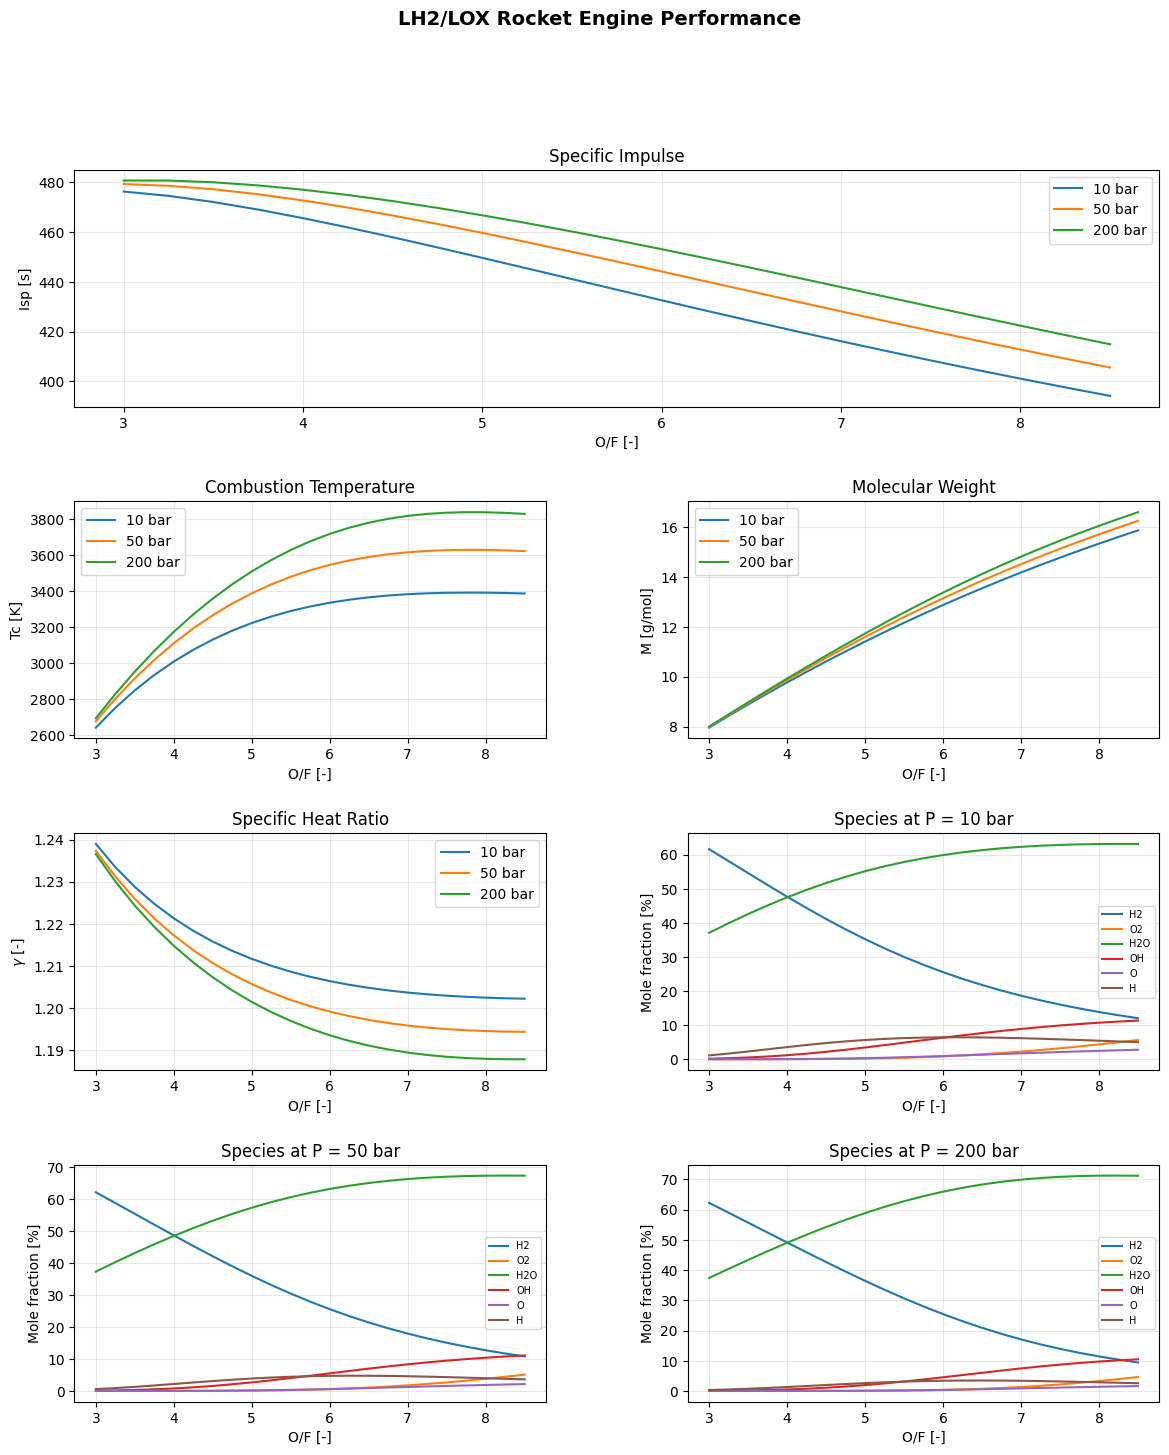

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

pressures = list(results.keys())

fig = plt.figure(figsize=(14, 16))
fig.suptitle('LH2/LOX Rocket Engine Performance', fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

ax_isp = fig.add_subplot(gs[0, :])
for P in pressures:
    OF_vals  = list(results[P].keys())
    Isp_vals = [results[P][OF]['Isp'] for OF in OF_vals]
    ax_isp.plot(OF_vals, Isp_vals, label=f'{P:.0f} bar')
ax_isp.set(xlabel='O/F [-]', ylabel='Isp [s]', title='Specific Impulse')
ax_isp.legend()
ax_isp.grid(True, alpha=0.3)

small_plots = [
    (1, 0, 'Tc',    'Tc [K]',       'Combustion Temperature'),
    (1, 1, 'M',     'M [g/mol]',    'Molecular Weight'),
    (2, 0, 'gamma', '$\gamma$ [-]', 'Specific Heat Ratio'),
]

for row, col, key, ylabel, title in small_plots:
    ax = fig.add_subplot(gs[row, col])
    for P in pressures:
        OF_vals = list(results[P].keys())
        vals    = [results[P][OF][key] for OF in OF_vals]
        ax.plot(OF_vals, vals, label=f'{P:.0f} bar')
    ax.set(xlabel='O/F [-]', ylabel=ylabel, title=title)
    ax.legend()
    ax.grid(True, alpha=0.3)

species_positions = [(2, 1), (3, 0), (3, 1)]

for (row, col), P in zip(species_positions, pressures):
    ax = fig.add_subplot(gs[row, col])
    OF_vals = list(results[P].keys())
    for sp in config['equilibrium_species']:
        fracs = [results[P][OF]['fractions'][sp] * 100 for OF in OF_vals]
        ax.plot(OF_vals, fracs, label=sp)
    ax.set(xlabel='O/F [-]', ylabel='Mole fraction [%]',
           title=f'Species at P = {P:.0f} bar')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.show()

In [9]:
# exporta ficheiro para os data engineers
def save_results_for_data_engineers(results_dict):
    """
    Otimização para o João Nave e o novo membro:
    Exporta os dados para CSV para não terem de correr o código sempre.
    """
    rows = []
    for P, of_data in results_dict.items():
        for OF, data in of_data.items():
            rows.append({
                'P_chamber': P,
                'OF_ratio': OF,
                'Isp': data['Isp'],
                'Tc': data['Tc'],
                'M': data['M']
            })
    pd.DataFrame(rows).to_csv('engine_results.csv', index=False)
save_results_for_data_engineers(results)